<a href="https://colab.research.google.com/github/ndvnthna/Proyek-KomRik/blob/main/IteraGo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== SYSTEM PREDIKSI KEBERANGKATAN KULIAH : IteraGo ===
1. Masukkan Jam Mulai Kuliah (HH.MM): 07.50
2. Masukkan Jarak ke Kampus (Km): 5
3. Masukkan Jeda Waktu di Kampus (menit): 5
-----------------------------------------------------------------
Hasil Analisis untuk Kuliah Pukul 07.50 WIB:
➔ Jarak Tempuh ke Kampus : 5.0 Km
➔ Estimasi Durasi Jalan  : 20 Menit
➔ Jeda Waktu Cadangan    : 5 Menit
➔ Disarankan berangkat   : Pukul 07:25 WIB
-----------------------------------------------------------------


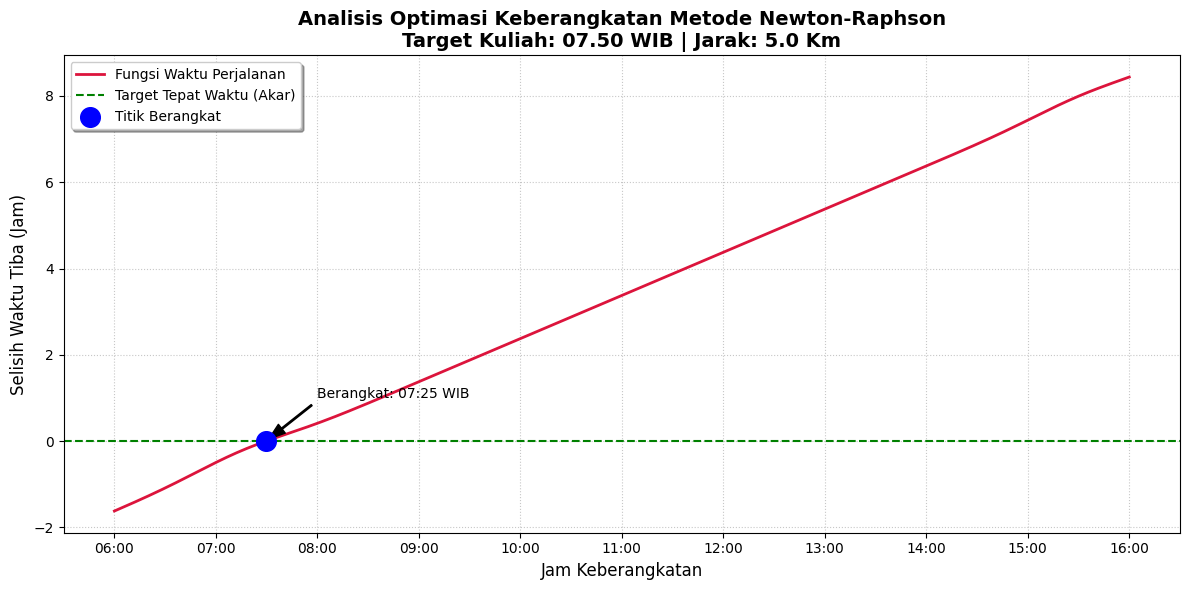

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Variabel Global untuk menampung input user
JAM_KULIAH_DESIMAL = 7.83  # Default 07.50
JARAK_KM = 6.0             # Default 6.0 Km

# =====================================================================
# PEMODELAN WAKTU PERJALANAN DINAMIS
# =====================================================================
def f(t):
    global JAM_KULIAH_DESIMAL, JARAK_KM
    waktu_perjalanan_dasar = JARAK_KM / 24.0

    # Model kemacetan
    macet_pagi = 0.5 * np.exp(-(t - 1.25)**2 / 0.4)
    macet_sore = 0.4 * np.exp(-(t - 9.5)**2 / 0.4)

    # TAMBAHAN: FAKTOR_MACET_TETAP (0.1) untuk mewakilSi macet
    # persimpangan/lampu merah
    FAKTOR_MACET_TETAP = 0.1
    total_hambatan = (JARAK_KM * 0.04 + FAKTOR_MACET_TETAP) * (macet_pagi + macet_sore)

    return t + waktu_perjalanan_dasar + total_hambatan - JAM_KULIAH_DESIMAL

def df(t):
    global JARAK_KM
    d_pagi = -2 * (t - 1.25) / 0.4 * 0.5 * np.exp(-(t - 1.25)**2 / 0.4)
    d_sore = -2 * (t - 9.5) / 0.4 * 0.4 * np.exp(-(t - 9.5)**2 / 0.4)

    # Sesuaikan turunan dengan konstanta macet tetap
    FAKTOR_MACET_TETAP = 0.1
    return 1 + (JARAK_KM * 0.04 + FAKTOR_MACET_TETAP) * (d_pagi + d_sore)

def hitung_jam_optimal(tebakan_awal, tol=1e-5, max_iter=100):
    t_sekarang = tebakan_awal
    log_iterasi = []
    for i in range(max_iter):
        ft = f(t_sekarang)
        dft = df(t_sekarang)
        if abs(dft) < 1e-12: t_sekarang += 0.1; continue
        t_baru = t_sekarang - (ft / dft)
        error = abs(t_baru - t_sekarang)
        log_iterasi.append((i+1, t_sekarang, ft, error))
        if error < tol: return t_baru, log_iterasi
        t_sekarang = t_baru
    return t_sekarang, log_iterasi

# =====================================================================
# INPUT INTERAKTIF & RUN SYSTEM
# =====================================================================
if __name__ == "__main__":
    print("=== SYSTEM PREDIKSI KEBERANGKATAN KULIAH : IteraGo ===")
    input_jam = input("1. Masukkan Jam Mulai Kuliah (HH.MM): ")
    input_jarak = input("2. Masukkan Jarak ke Kampus (Km): ")
    input_buffer = input("3. Masukkan Jeda Waktu di Kampus (menit): ")

    try:
        JARAK_KM = float(input_jarak)
        buffer_jam = float(input_buffer) / 60.0

        bagian = input_jam.split('.')
        JAM_KULIAH_DESIMAL = (int(bagian[0]) - 6) + (int(bagian[1]) / 60.0)

        t_optimal, log_data = hitung_jam_optimal(JAM_KULIAH_DESIMAL - 0.5)

        total_jam_nyata = 6 + t_optimal - buffer_jam
        jam_final = int(total_jam_nyata)
        menit_final = int(round((total_jam_nyata - jam_final) * 60))

        durasi_menit = int(round((JAM_KULIAH_DESIMAL - t_optimal) * 60))

        print("-" * 65)
        print(f"Hasil Analisis untuk Kuliah Pukul {input_jam} WIB:")
        print(f"➔ Jarak Tempuh ke Kampus : {JARAK_KM} Km")
        print(f"➔ Estimasi Durasi Jalan  : {durasi_menit} Menit")
        print(f"➔ Jeda Waktu Cadangan    : {input_buffer} Menit")
        print(f"➔ Disarankan berangkat   : Pukul {jam_final:02d}:{menit_final:02d} WIB")
        print("-" * 65)

        # =====================================================
        # VISUALISASI GRAFIK 
        # =====================================================
        t_plot = np.linspace(0, 10, 300)
        sisa_waktu_plot = [f(tp) for tp in t_plot]

        plt.figure(figsize=(12, 6))
        plt.plot(t_plot, sisa_waktu_plot, color='crimson', label='Fungsi Waktu Perjalanan', linewidth=2)
        plt.axhline(0, color='green', linestyle='--', linewidth=1.5, label='Target Tepat Waktu (Akar)')

        # Titik Rekomendasi
        plt.scatter(t_optimal, 0, color='blue', s=200, zorder=5, label='Titik Berangkat')

        # Menambahkan Anotasi (Teks keterangan) pada titik
        plt.annotate(f'Berangkat: {jam_final:02d}:{menit_final:02d} WIB',
                     xy=(t_optimal, 0), xytext=(t_optimal + 0.5, 1),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

        # Pengaturan Sumbu
        plt.xticks(np.arange(0, 11, 1), [f"{6+i:02d}:00" for i in range(11)])

        # Memberi label dan judul yang informatif
        plt.title(f'Analisis Optimasi Keberangkatan Metode Newton-Raphson\nTarget Kuliah: {input_jam} WIB | Jarak: {JARAK_KM} Km',
                  fontsize=14, fontweight='bold')
        plt.xlabel('Jam Keberangkatan', fontsize=12)
        plt.ylabel('Selisih Waktu Tiba (Jam)', fontsize=12)

        # Menambah grid yang lebih halus
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.legend(loc='upper left', frameon=True, shadow=True)

        plt.tight_layout()
        plt.show()

    except Exception:
        print("\nInput salah! Pastikan menggunakan titik (.) untuk jam (contoh: 15.51).")